# HANDLING MISSING DATA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('data_science_job (1).csv')
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


### Finding Missing Data Columns Wise

In [3]:
df.isnull().mean()*100

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [4]:
df.shape

(19158, 13)

### Selected Column Name (Below 5%)

In [5]:
cols = [var for var in df.columns if 
        df [var].isnull().mean() < 0.05 and 
        df[var].isnull().mean() > 0]

In [6]:
cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [7]:
df[cols].sample(5)

,city_development_index,enrolled_university,education_level,experience,training_hours
2495,0.624,Full time course,High School,4.0,12.0
8003,0.743,no_enrollment,High School,4.0,14.0
17454,0.923,no_enrollment,Phd,9.0,12.0
6819,0.767,Full time course,High School,3.0,68.0
1487,0.804,no_enrollment,Masters,10.0,32.0


### Calculated Drop Rows

In [8]:
len(df[cols].dropna()) / len(df)

0.8968577095730244

### Create New Data Frame

In [9]:
new_df = df[cols].dropna()
df.shape, new_df.shape

((19158, 13), (17182, 5))

### Plot Histogram (Applying CCA: Numerical Data)

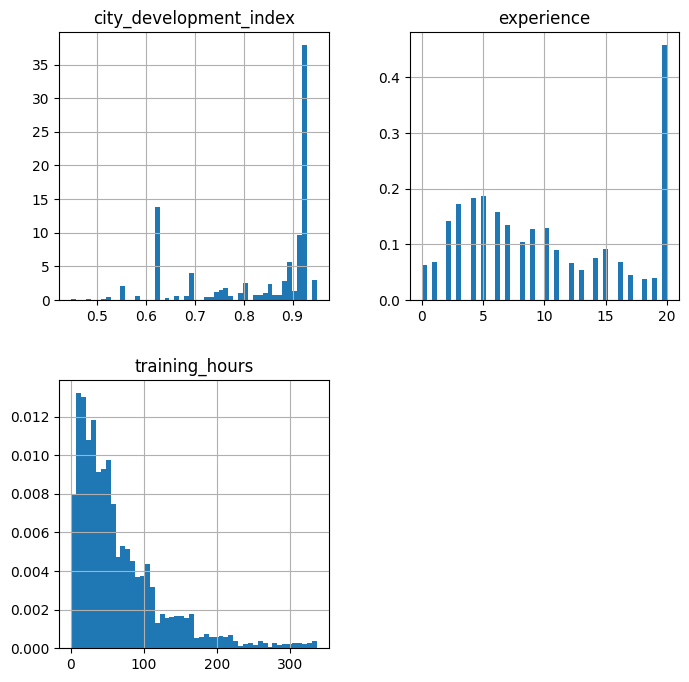

In [10]:
new_df.hist(bins=50, density=True, figsize=(8,8))
plt.show()

### Plot Histogram: Training Hours

<Axes: >

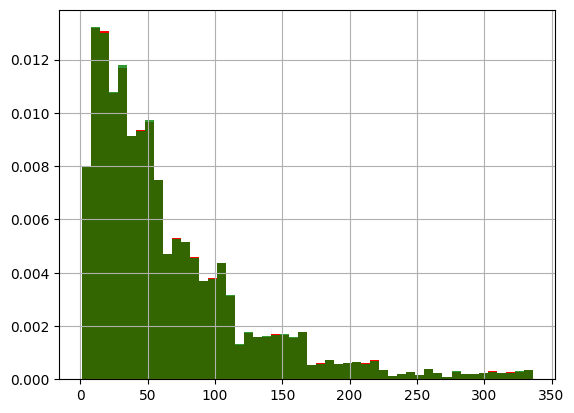

In [11]:
fig = plt.figure()
ax = fig.add_subplot(111)

# Original Data
df['training_hours'].hist(bins=50, ax=ax, density=True, color='red')

# Data after cca, the argument alpha makes the color transparent, so we can
# See the overlay of the 2 distributions
new_df['training_hours'].hist(bins=50, ax=ax, color='green', density=True, alpha=0.8)

### Plot Probability Density Function (PDF): Training Hours

<Axes: ylabel='Density'>

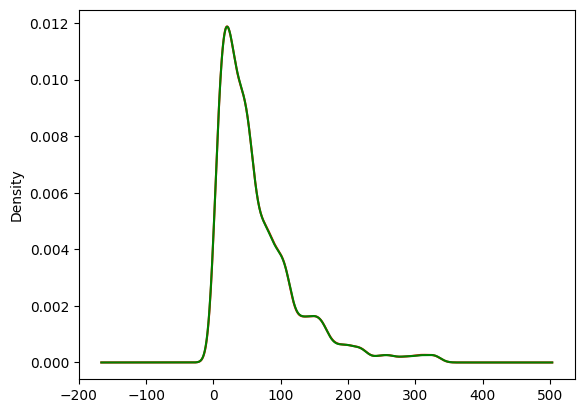

In [12]:
fig = plt.figure()
ax = fig.add_subplot(111)

# Original Data
df['training_hours'].plot.density(color='red')

# Data After cca
new_df['training_hours'].plot.density(color='green')

### Plot Histogram: City Development

<Axes: >

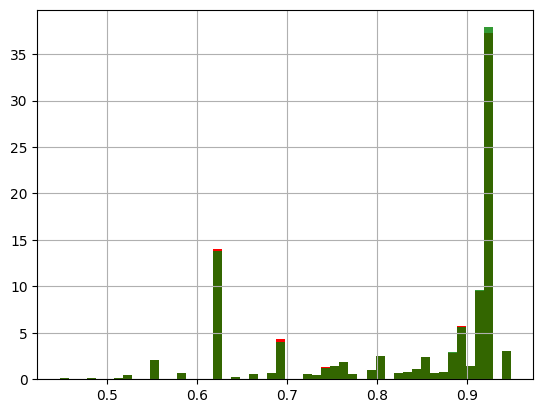

In [13]:
fig = plt.figure()
ax = fig.add_subplot(111)

# Original Data
df['city_development_index'].hist(bins=50, ax=ax, density=True, color='red')

# Data after cca, the argument alpha makes the color transparent, so we can
# See the overlay of the 2 distributions
new_df['city_development_index'].hist(bins=50, ax=ax, color='green', density=True, alpha=0.8)

### Plot PDF: City Development

<Axes: ylabel='Density'>

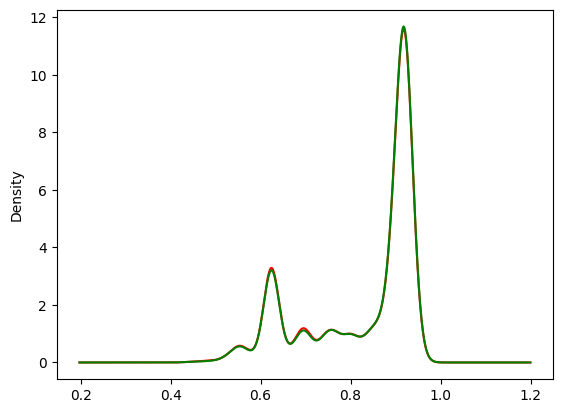

In [14]:
fig = plt.figure()
ax = fig.add_subplot(111)

# Original Data
df['city_development_index'].plot.density(color='red')

# Data After cca
new_df['city_development_index'].plot.density(color='green')

### Plot Histogram: Experience

<Axes: >

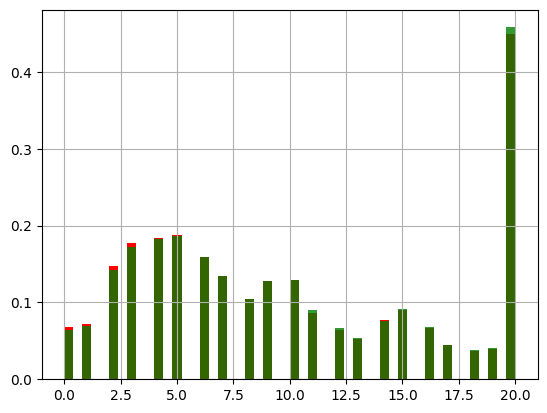

In [15]:
fig = plt.figure()
ax = fig.add_subplot(111)

# Original Data
df['experience'].hist(bins=50, ax=ax, density=True, color='red')

# Data after cca, the argument alpha makes the color transparent, so we can
# See the overlay of the 2 distributions
new_df['experience'].hist(bins=50, ax=ax, color='green', density=True, alpha=0.8)

### Plot PDF: Experience

<Axes: ylabel='Density'>

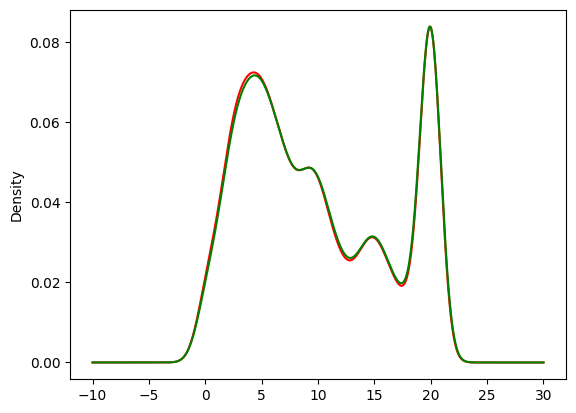

In [16]:
fig = plt.figure()
ax = fig.add_subplot(111)

# Original Data
df['experience'].plot.density(color='red')

# Data After cca
new_df['experience'].plot.density(color='green')

### CCA in Categorical Data

In [17]:
df['education_level'].value_counts()

education_level
Graduate          11598
Masters            4361
High School        2017
Phd                 414
Primary School      308
Name: count, dtype: int64

### CCA Apply in Enrolled University

In [19]:
temp = pd.concat([
    # percentage of observations per category, original data
    df['enrolled_university'].value_counts() / len(df),
    # percentage of observations per category, cca data
    new_df['enrolled_university'].value_counts() / len(new_df)], axis=1)

# add columns name
temp.columns = ['original', 'cca']
temp

,original,cca
enrolled_university,,
no_enrollment,0.721213,0.735188
Full time course,0.196106,0.200733
Part time course,0.062533,0.064079
